# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [74]:
df = pd.read_csv("info.csv")
cgpa_top = df.sort_values(by="CGPA", ascending=False).head(15)
time_spent = cgpa_top.loc[:, ["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]]
time_spent

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
657,22,6.85,8.45,3.84,12.67
109,23,5.83,9.26,7.19,6.05
843,24,4.64,8.34,3.28,3.59
405,17,6.87,7.92,2.21,18.13
464,25,5.18,9.13,7.92,7.85
171,20,8.05,7.34,6.46,0.00
475,19,5.71,8.07,2.98,12.96
639,19,7.30,8.57,3.96,8.24
659,20,3.85,9.22,7.14,5.21
682,25,4.87,8.25,4.95,0.00


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około pół godziny czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [54]:
time_spent["Free_time_per_Day"] = 24 - 2.5 + 0.5 - time_spent[["Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours"]].sum(axis=1)
# 24 godziny doby - 2.5 na jedzenie + 0.5 pokrywająca się godzina z nauki i screen time (wszsyscy uczniowie maja ponad 0.5 screen time)

time_spent["Free_time_per_Day"] -= (time_spent[ "Gym_Hours_per_Week"] / 7).round(2)


time_spent[["Free_time_per_Day", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]]



,Free_time_per_Day,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
657,1.05,6.85,8.45,3.84,12.67
109,-1.14,5.83,9.26,7.19,6.05
843,5.23,4.64,8.34,3.28,3.59
405,2.41,6.87,7.92,2.21,18.13
464,-1.35,5.18,9.13,7.92,7.85
171,0.15,8.05,7.34,6.46,0.00
475,3.39,5.71,8.07,2.98,12.96
639,0.99,7.30,8.57,3.96,8.24
659,1.05,3.85,9.22,7.14,5.21
682,3.93,4.87,8.25,4.95,0.00


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [ ]:
stress = df.loc[df['Age']>=18, ['Branch', 'Stress_Level_1_to_10']]
col1 = stress.groupby('Branch').mean().sort_values('Stress_Level_1_to_10', ascending=False)

sleep = df.loc[df['Age']>=18, ['Branch', 'Sleep_Hours']]
col2 = sleep.groupby('Branch').median()

result = pd.concat([col1, col2], axis=1, join="inner")
result


,Stress_Level_1_to_10,Sleep_Hours
Branch,,
Civil,4.630494,6.710
ECE,4.626014,6.405
Mechanical,4.608940,6.640
Electrical,4.544621,6.310
CSE,4.526667,6.540
IT,4.454929,6.755


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

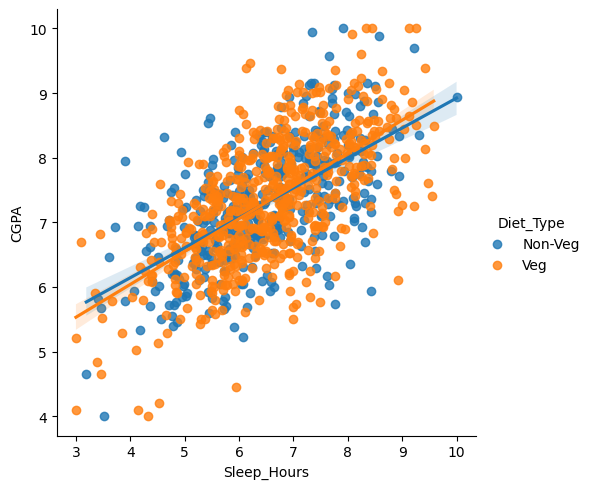

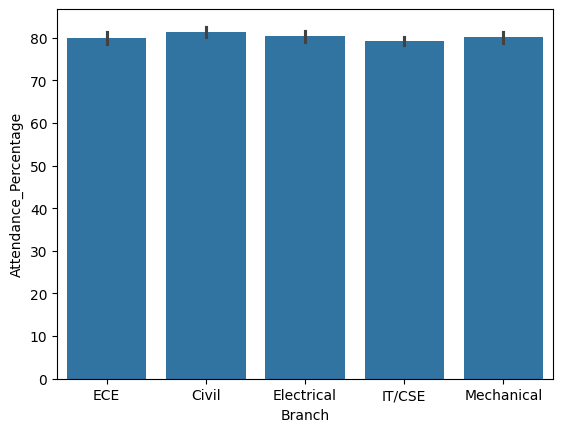

In [37]:
dot1 = df[['Diet_Type', 'Sleep_Hours', 'CGPA']]

dot2 = df[['Branch', 'Attendance_Percentage']].copy()
dot2['Branch'] = dot2['Branch'].replace({
    'CSE': 'IT/CSE',
    'IT': 'IT/CSE'
})

sns.lmplot(data=dot1, x="Sleep_Hours", y="CGPA", hue="Diet_Type")
plt.show()

sns.barplot(data=dot2, x="Branch", y="Attendance_Percentage")
plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

<Axes: xlabel='platform', ylabel='sum_rates'>

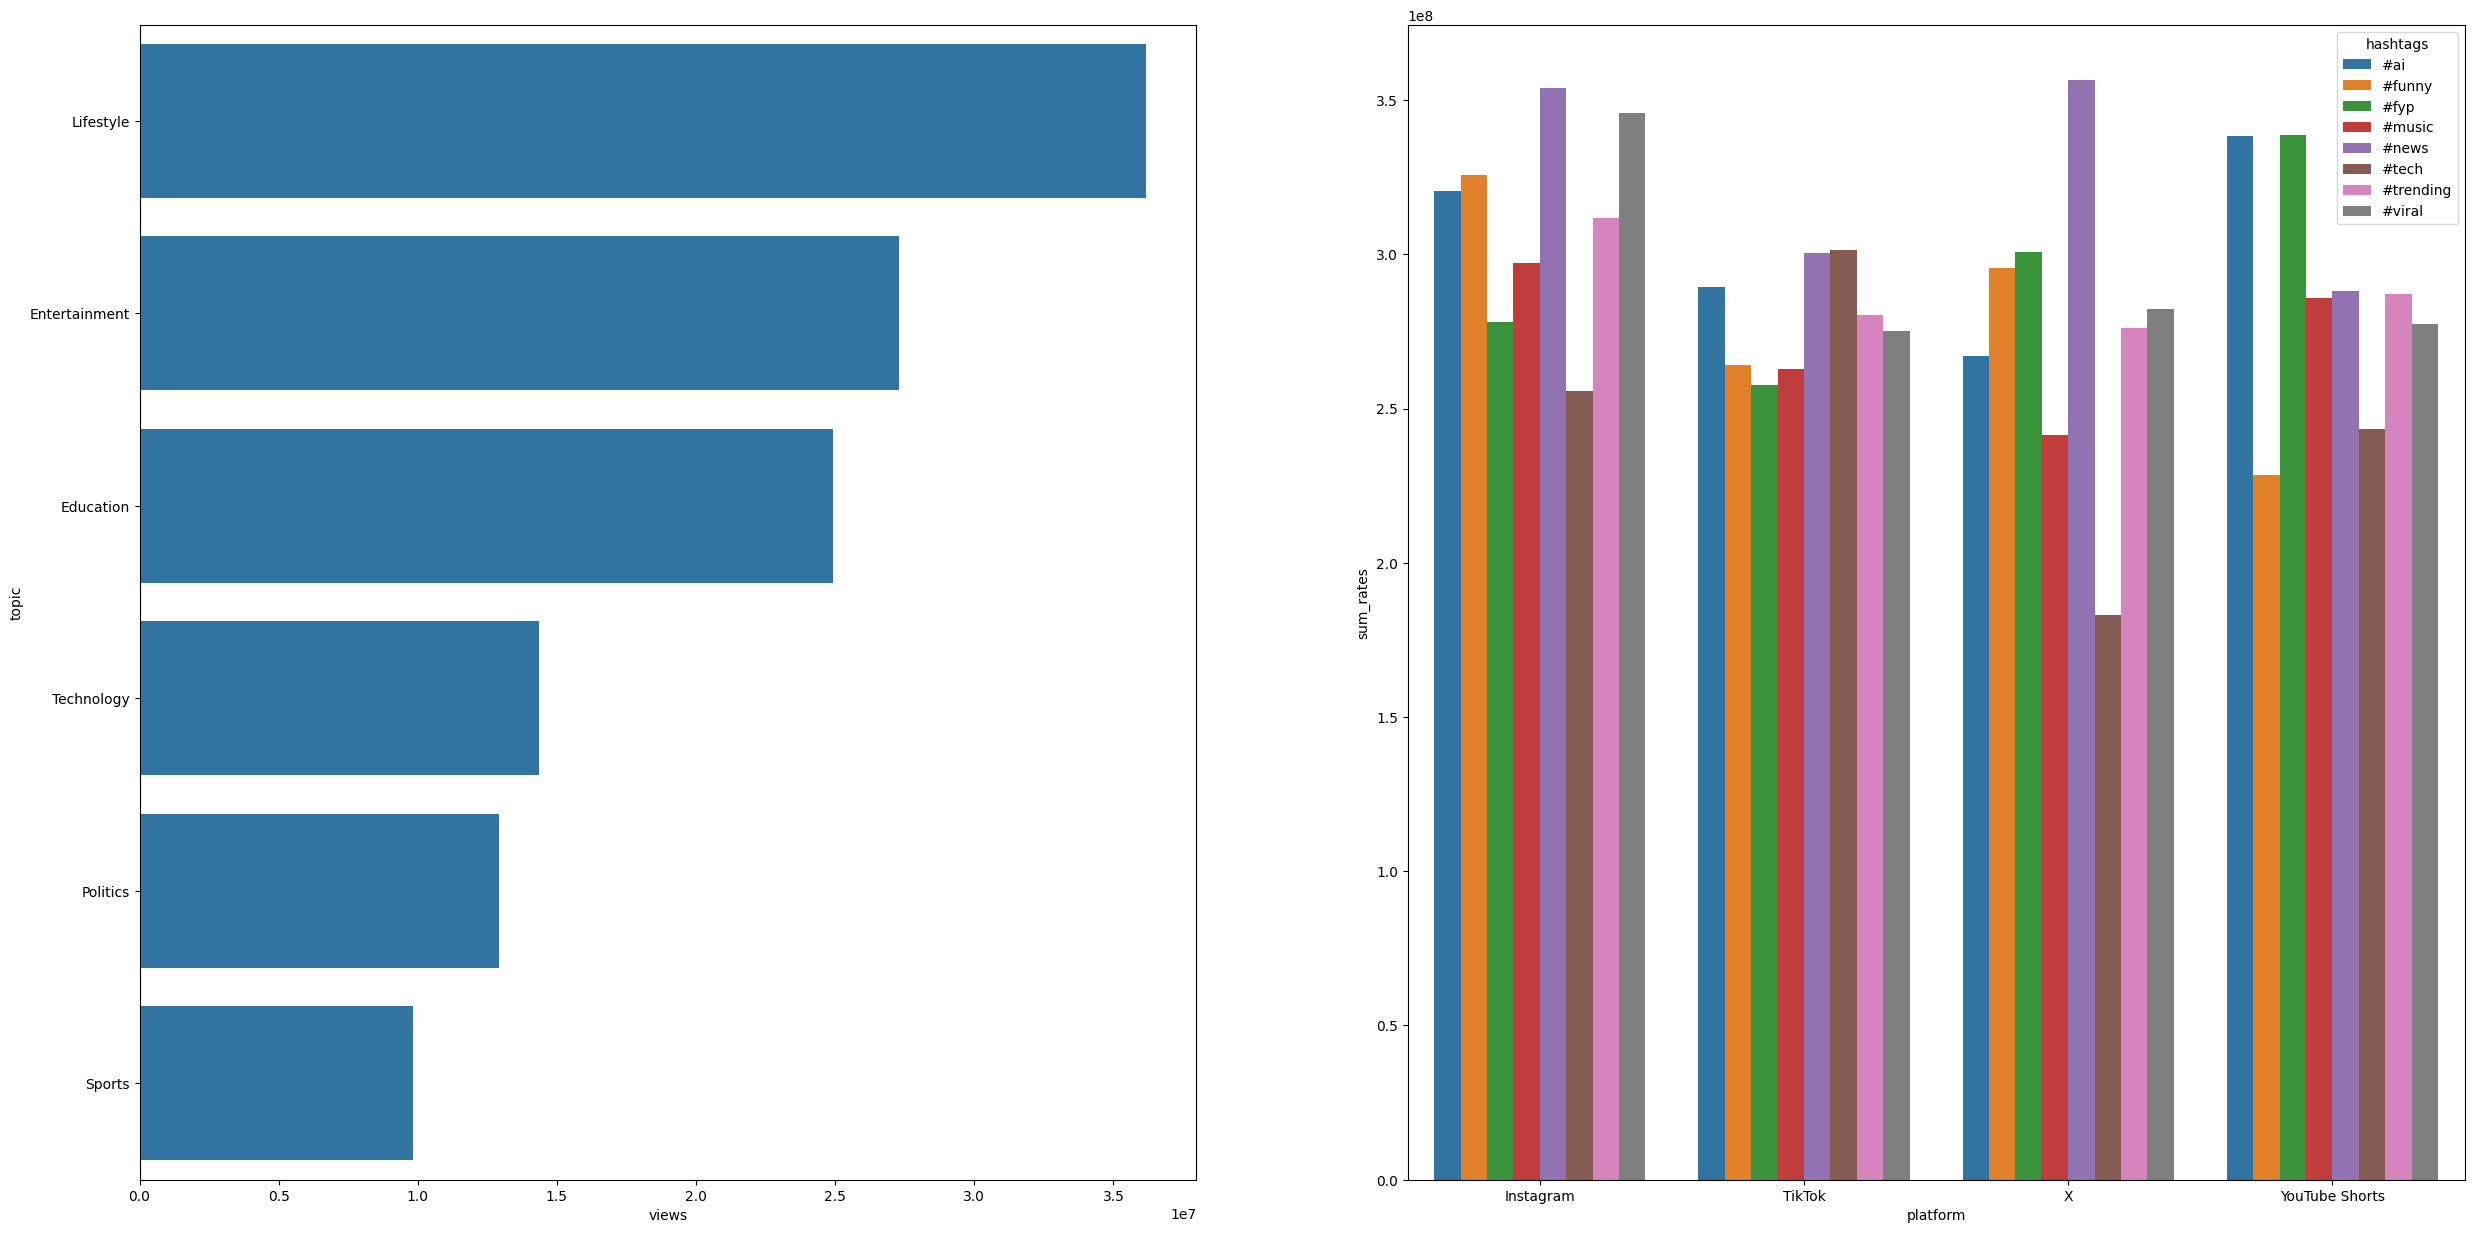

In [75]:
df2 = pd.read_csv("social_media_viral_content_dataset.csv")

conditions = (df2['post_datetime'] > '2024-10-01 00:00:00') & (df2['platform'] == 'YouTube Shorts') & (df2['content_type'] == 'video')
topics = df2.loc[conditions, ['topic', 'views']].groupby('topic').sum().sort_values('views', ascending=False)

hash_rates = df2[['platform', 'hashtags']].copy()
hash_rates["sum_rates"] = df2[['views', 'likes', 'comments', 'shares']].sum(axis=1)
hash_rates['hashtags'] = hash_rates['hashtags'].str.split(' ').explode('hashtags')
hash_rates = hash_rates.groupby(['platform', 'hashtags']).sum().reset_index()


fig2, axes2 = plt.subplots(1, 2, figsize=(30, 15))

sns.barplot(data=topics, x='views', y=topics.index, ax=axes2[0])
sns.barplot(data=hash_rates, x=hash_rates['platform'], y=hash_rates['sum_rates'], hue=hash_rates['hashtags'], ax=axes2[1])
